Credit Score Dataset:
    Income  LoanAmount  CreditHistory  CreditScore Class
0    25000       50000              1          300  Poor
1    30000       55000              1          320  Poor
2    35000       60000              1          350  Poor
3    40000       65000              1          380  Poor
4    45000       70000              1          400  Poor
5    50000       60000              1          450  Poor
6    55000       65000              1          480  Poor
7    60000       70000              1          500  Poor
8    65000       75000              1          550  Good
9    70000       70000              1          580  Good
10   75000       65000              1          620  Good
11   80000       60000              1          650  Good
12   85000       55000              1          680  Good
13   90000       50000              1          720  Good
14   95000       45000              1          750  Good
15  100000       40000              1          780  Good
16   2800

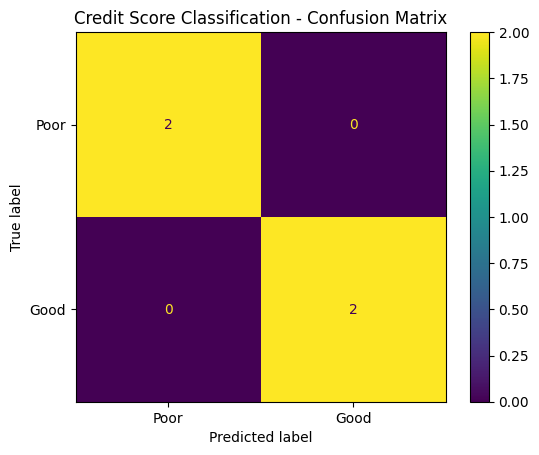


New Customer Details:
Income: ₹75,000
Loan Amount: ₹60,000
Credit History: Good
Credit Score: 680

Predicted Credit Classification:
Good Credit


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Experiment 11: Credit Score Classification
# Aim: Implement a machine learning model for
#      Credit Score Classification.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


# ---------------------------------------------------------
# STEP 1: Create a basic credit score dataset
# ---------------------------------------------------------

data = {
    'Income': [
        25000, 30000, 35000, 40000, 45000,
        50000, 55000, 60000, 65000, 70000,
        75000, 80000, 85000, 90000, 95000,
        100000, 28000, 32000, 42000, 58000
    ],

    'LoanAmount': [
        50000, 55000, 60000, 65000, 70000,
        60000, 65000, 70000, 75000, 70000,
        65000, 60000, 55000, 50000, 45000,
        40000, 60000, 70000, 80000, 65000
    ],

    'CreditHistory': [
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 0, 0, 0, 1
    ],

    'CreditScore': [
        300, 320, 350, 380, 400,
        450, 480, 500, 550, 580,
        620, 650, 680, 720, 750,
        780, 310, 330, 370, 520
    ],

    'Class': [
        'Poor', 'Poor', 'Poor', 'Poor', 'Poor',
        'Poor', 'Poor', 'Poor', 'Good', 'Good',
        'Good', 'Good', 'Good', 'Good', 'Good',
        'Good', 'Poor', 'Poor', 'Poor', 'Good'
    ]
}

df = pd.DataFrame(data)

print("Credit Score Dataset:")
print(df)


# ---------------------------------------------------------
# STEP 2: Convert target classes into numerical values
# ---------------------------------------------------------

df['Class'] = df['Class'].map({
    'Poor': 0,
    'Good': 1
})


# ---------------------------------------------------------
# STEP 3: Select input features and target
# ---------------------------------------------------------

X = df[
    ['Income', 'LoanAmount', 'CreditHistory', 'CreditScore']
]

y = df['Class']


# ---------------------------------------------------------
# STEP 4: Split dataset into training and testing data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------------
# STEP 5: Create Logistic Regression model
# ---------------------------------------------------------

model = LogisticRegression(max_iter=1000)


# ---------------------------------------------------------
# STEP 6: Train the model
# ---------------------------------------------------------

model.fit(X_train, y_train)


# ---------------------------------------------------------
# STEP 7: Predict test data
# ---------------------------------------------------------

y_pred = model.predict(X_test)


# ---------------------------------------------------------
# STEP 8: Calculate accuracy
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 50)
print("CREDIT SCORE CLASSIFICATION RESULTS")
print("=" * 50)

print("\nAccuracy:", round(accuracy * 100, 2), "%")


# ---------------------------------------------------------
# STEP 9: Display confusion matrix
# ---------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Poor', 'Good']
)

disp.plot()

plt.title("Credit Score Classification - Confusion Matrix")
plt.show()


# ---------------------------------------------------------
# STEP 10: Classify a new customer
# ---------------------------------------------------------

new_customer = np.array([
    [75000, 60000, 1, 680]
])

prediction = model.predict(new_customer)

if prediction[0] == 1:
    result = "Good Credit"
else:
    result = "Poor Credit"

print("\nNew Customer Details:")
print("Income: ₹75,000")
print("Loan Amount: ₹60,000")
print("Credit History: Good")
print("Credit Score: 680")

print("\nPredicted Credit Classification:")
print(result)